In [1]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from MDPSetup import create_state_space, create_action_space, create_P, create_R, cL_value_update_func
from ValueIteration import *
from typing import Tuple, List

# 2-echelon problem with lead times at DC only

## Centralised problem

In [24]:
# Problem parameters
capacity = (-400, 400)
increment = 100
lead_times = [1, 1]
n_ech = 2
demand_dist = {0: 0.2, 100: 0.6, 200: 0.2}
max_demand = max(demand_dist.keys())
hold_costs = [1, 0.5]
backlog_costs = [50, 25]

# Perform value iteration
gamma = 0.999
S, state_idx = create_state_space(capacity, increment, n_ech, max_demand, lead_times)
A, action_idx = create_action_space(capacity, increment, n_ech, max_demand)
P = create_P(S, A, state_idx, action_idx, demand_dist, capacity, n_ech, lead_times)
R = create_R(S, A, state_idx, action_idx, demand_dist, hold_costs, backlog_costs, n_ech, lead_times)
bellman_eq_cL = cL_value_update_func(state_idx, action_idx, capacity, demand_dist)
V_init = dict([(s, 0) for s in S])


In [25]:

# # Code to check transition probabilities
for s in S:
    s_idx = state_idx[s]
    for a in A:
        a_idx = action_idx[a]
        if sum(P[s_idx, a_idx, state_idx[s_next]] for s_next in S) != 1:
            print(s, a)
            print([(s_next, P[s_idx, a_idx, state_idx[s_next]]) for s_next in S if P[s_idx, a_idx, state_idx[s_next]] > 0])
            

In [38]:
print(len(S))
print(S)

3969
[(-400, -400, 0, 0), (-400, -400, 0, 100), (-400, -400, 0, 200), (-400, -400, 0, 300), (-400, -400, 0, 400), (-400, -400, 0, 500), (-400, -400, 0, 600), (-400, -400, 100, 0), (-400, -400, 100, 100), (-400, -400, 100, 200), (-400, -400, 100, 300), (-400, -400, 100, 400), (-400, -400, 100, 500), (-400, -400, 100, 600), (-400, -400, 200, 0), (-400, -400, 200, 100), (-400, -400, 200, 200), (-400, -400, 200, 300), (-400, -400, 200, 400), (-400, -400, 200, 500), (-400, -400, 200, 600), (-400, -400, 300, 0), (-400, -400, 300, 100), (-400, -400, 300, 200), (-400, -400, 300, 300), (-400, -400, 300, 400), (-400, -400, 300, 500), (-400, -400, 300, 600), (-400, -400, 400, 0), (-400, -400, 400, 100), (-400, -400, 400, 200), (-400, -400, 400, 300), (-400, -400, 400, 400), (-400, -400, 400, 500), (-400, -400, 400, 600), (-400, -400, 500, 0), (-400, -400, 500, 100), (-400, -400, 500, 200), (-400, -400, 500, 300), (-400, -400, 500, 400), (-400, -400, 500, 500), (-400, -400, 500, 600), (-400, -400,

In [26]:

cL_results = value_iteration(S, A, P, R, gamma, max_iterations = 100,
                                 bellman_eq=bellman_eq_cL, V_init = V_init, theta = 1e-7)
cL_optimal_policy = cL_results["optimal_policy"]
cL_cost_function = cL_results["value_function"]

In [27]:
cL_optimal_policy

{(-400, -400, 0, 0): (0, 600),
 (-400, -400, 0, 100): (0, 600),
 (-400, -400, 0, 200): (0, 500),
 (-400, -400, 0, 300): (0, 400),
 (-400, -400, 0, 400): (0, 300),
 (-400, -400, 0, 500): (100, 200),
 (-400, -400, 0, 600): (200, 100),
 (-400, -400, 100, 0): (0, 600),
 (-400, -400, 100, 100): (0, 600),
 (-400, -400, 100, 200): (0, 500),
 (-400, -400, 100, 300): (0, 400),
 (-400, -400, 100, 400): (0, 300),
 (-400, -400, 100, 500): (100, 200),
 (-400, -400, 100, 600): (200, 100),
 (-400, -400, 200, 0): (0, 600),
 (-400, -400, 200, 100): (0, 600),
 (-400, -400, 200, 200): (0, 500),
 (-400, -400, 200, 300): (0, 400),
 (-400, -400, 200, 400): (0, 300),
 (-400, -400, 200, 500): (100, 200),
 (-400, -400, 200, 600): (100, 100),
 (-400, -400, 300, 0): (0, 600),
 (-400, -400, 300, 100): (0, 500),
 (-400, -400, 300, 200): (0, 400),
 (-400, -400, 300, 300): (0, 300),
 (-400, -400, 300, 400): (0, 200),
 (-400, -400, 300, 500): (0, 100),
 (-400, -400, 300, 600): (0, 0),
 (-400, -400, 400, 0): (0, 500),

In [30]:
store_results(cL_results, 2, "c1-1", 400, 600, backlog_costs, hold_costs, gamma)

# Plotting Code
## Plotting functions

In [31]:
def calculate_ip(state: tuple, lead_times: List, n_ech: int):
    ''' Calculates the inventory position for each site in the supply chain'''
    ips = []
    next_lead_idx = n_ech
    for ech in range(n_ech): # for each site
        ips.append(state[ech] + sum(state[next_lead_idx:next_lead_idx+lead_times[ech]])) # add inventory level + outstanding orders for the current site
        next_lead_idx += lead_times[ech]

    return tuple(ips)

In [33]:


def make_policy_plot_dict(optimal_dict: Dict, lead_times: List, n_ech: int, system_type: str ="Centralised"):
    IPs = sorted(set(calculate_ip(state, lead_times, n_ech) for state in optimal_dict)) 
    
    # DC_pol = dict((x1, [[], []]) for (x1, x2) in IPs)  # Storing W IP and W order quantity for each DC IP (key)

    # if system_type == "Centralised":
    #     W_pol = dict((x2, [[], []]) for (x1, x2) in IPs)   # Storing DC IP and DC order quantity for each W IP (key)

    #     for state, (q_dc, q_w) in optimal_dict.items():
    #         ip_dc, ip_w = calculate_ip(state, lead_times, n_ech)
    #         # print(state, ip_dc, ip_w)
    #         DC_pol[ip_dc][0].append(ip_w)
    #         DC_pol[ip_dc][1].append(q_w)
    #         W_pol[ip_w][0].append(ip_dc)
    #         W_pol[ip_w][1].append(q_dc)

    #     return DC_pol, W_pol
    
    W_policy = dict((ip_dc, set()) for (ip_dc, ip_w) in IPs)

    if system_type == "Centralised":
        DC_policy = dict((ip_w, set()) for (ip_dc, ip_w) in IPs)

        for state, (q_dc, q_w) in optimal_dict.items():
            ip_dc, ip_w = calculate_ip(state, lead_times, n_ech)

            W_policy[ip_dc].add((ip_w, q_w))
            DC_policy[ip_w].add((ip_dc, q_dc))

        return W_policy, DC_policy

    
    # else: # COMPLETE FOR DECENTRALISED SYSTEM



def generate_policy_plot(optimal_dict: Dict, bounds: tuple, 
                         lead_times: List, n_ech: int, system_type: str = "Centralised", 
                         colour_by: str = "DC", bbox_to_anchor=None, savefig=False):
    if system_type == "Centralised":
        W_policy, DC_policy = make_policy_plot_dict(optimal_dict, lead_times, n_ech, system_type)
    else:
        W_policy = make_policy_plot_dict(optimal_dict, lead_times, n_ech, system_type)

    
    plot_pol = W_policy if colour_by == "DC" else DC_policy
    x_site = "warehouse" if colour_by == "DC" else "DC"

    cmap = plt.get_cmap("tab20")
    keys = sorted(plot_pol.keys())
    colors = cmap([i / (len(keys) - 1) for i in range(len(keys))])

    fig, ax = plt.subplots()

    for il, color in zip(keys, colors):
        if bounds[0] <= il <= bounds[1]:
            sorted_pol = sorted(plot_pol[il])
            ips, order_sizes = zip(*sorted_pol)
            label = il if bounds[0] < il < bounds[1] else rf"$\geq {bounds[1]}$" if il >= bounds[1] else rf"$\leq {bounds[0]}$"
            plt.plot(ips, order_sizes, label=label, color=color, linestyle="--", linewidth=1, marker = ".", markersize=10)

    
    # filename=f"Figures/multi_echelon/policy_{'c0' if system_type=='centralised' else 'dc0'}_leg{colour_by}_cap{capacity}_MOQ{maxA}_sl{cb[0]*100/(cb[0]+h[0]):.1f}.{format}"   # filename
    plt.xlabel(f"Inventory position at {x_site}", fontsize=18)
    plt.ylabel("Optimal order quantity", fontsize=18)
    # plt.title(f"Optimal policy at {x_site} coloured by inventory position at {colour_by}")
    plt.legend(title=f"{colour_by} IP", bbox_to_anchor=bbox_to_anchor, fontsize=14, title_fontsize=14)
    plt.grid()
    plt.tight_layout()
    # if savefig:
    #     plt.savefig(filename, dpi=300)
    plt.show()



    

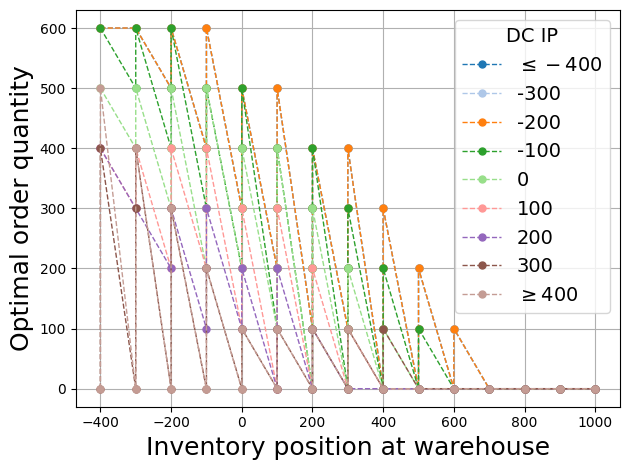

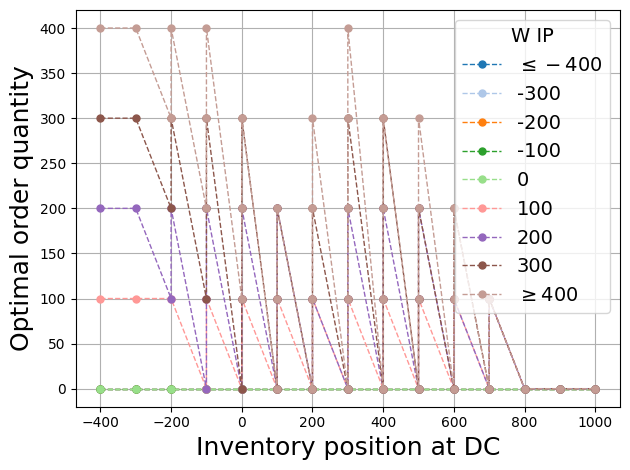

In [37]:
make_policy_plot_dict(cL_optimal_policy, lead_times, 2)[0]
generate_policy_plot(cL_optimal_policy, (-400, 400), lead_times, n_ech=2, colour_by="DC")
generate_policy_plot(cL_optimal_policy, (-400, 400), lead_times, n_ech=2, colour_by="W")

In [39]:
# make_policy_plot_dict(cL_optimal_policy, lead_times, 2)[0]

In [40]:
# cL_optimal_policy

In [41]:
# cL11_results = pickle.load(open(fr'PolicyResults/2ech_c1-1_cap400_MOQ600_sl98.0_gamma0.999.pkl', "rb"))
# cL11_policy = cL11_results["optimal_policy"]
# cL11_policy